# Entrenamiento y Evaluación de Modelos de Machine Learning

Este cuaderno ejecuta el pipeline analítico para los modelos supervisados: Regresión Lineal, Random Forest y XGBoost. De acuerdo con la metodología establecida, se estructuran características temporales (Lag Features y Rolling Means) para permitir que los algoritmos procesen series de tiempo. 

Para evitar la fuga de datos (data leakage), el dataset se divide cronológicamente, reservando los datos desde enero de 2026 en adelante exclusivamente como conjunto de validación. Finalmente, se evalúa la capacidad de ajuste mediante las métricas MAE, RMSE y R2.


El holdout usa semanas etiquetadas antes de `2026-01-01` para desarrollo y desde esa fecha para test. Como una semana termina en domingo, la primera semana de test es 2026-01-04 e incluye el 29–31 de diciembre. El último bloque puede contener una semana parcial de agosto, aunque las transacciones terminan en julio. Se reportan ambos rangos sin reasignar transacciones ni cortar semanas silenciosamente.

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# 1. Cargar el dataset transaccional
print("Cargando base de datos...")
df = pd.read_csv("../datasets/dataset_maestro_dashboard.csv")
df['fecdoc'] = pd.to_datetime(df['fecdoc'])

# Ordenar cronológicamente para evitar contaminación en los rezagos
df = df.sort_values(by=['sucursal', 'producto', 'fecdoc']).reset_index(drop=True)

# 2. Ingeniería de Características por Sucursal y Producto
print("Construyendo variables predictivas (Lags y Medias Móviles)...")

df['lag_1'] = df.groupby(['sucursal', 'producto'])['cantidad'].shift(1)
df['lag_7'] = df.groupby(['sucursal', 'producto'])['cantidad'].shift(7)
df['lag_14'] = df.groupby(['sucursal', 'producto'])['cantidad'].shift(14)
df['lag_30'] = df.groupby(['sucursal', 'producto'])['cantidad'].shift(30)

df['rolling_mean_7'] = df.groupby(['sucursal', 'producto'])['cantidad'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df['rolling_mean_30'] = df.groupby(['sucursal', 'producto'])['cantidad'].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())

df['mes'] = df['fecdoc'].dt.month
df['dia_semana'] = df['fecdoc'].dt.dayofweek

# Eliminar nulos generados por los desplazamientos iniciales
df = df.dropna().reset_index(drop=True)

# 3. Codificación de variables categóricas
columnas_categoricas = ['sucursal', 'producto']
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

print("Preprocesamiento finalizado con éxito.")

Cargando base de datos...
Construyendo variables predictivas (Lags y Medias Móviles)...


Preprocesamiento finalizado con éxito.


## Partición Temporal y Clase Evaluadora

Se implementa la validación temporal estricta mediante `TimeSeriesSplit` y se encapsula la lógica de entrenamiento en una clase orientada a objetos. Esto garantiza la transparencia experimental al someter los tres algoritmos a idénticas condiciones de prueba.

In [2]:
# 1. Partición Temporal Estricta (Enero 2024 - Diciembre 2025 vs Enero 2026 - Julio 2026)
fecha_corte = '2026-01-01'

# TimeSeriesSplit recorre filas: ordenar globalmente después de calcular los rezagos por serie.
df_encoded = df_encoded.sort_values('fecdoc', kind='stable')

df_train = df_encoded[df_encoded['fecdoc'] < fecha_corte].copy()
df_test = df_encoded[df_encoded['fecdoc'] >= fecha_corte].copy()

# Variables a excluir de las predictoras
columnas_a_excluir = ['fecdoc', 'cantidad', 'categoria_abc']

X_train_bruto = df_train.drop(columns=[col for col in columnas_a_excluir if col in df_train.columns])
y_train = df_train['cantidad']

X_test_bruto = df_test.drop(columns=[col for col in columnas_a_excluir if col in df_test.columns])
y_test = df_test['cantidad']

# --- FILTRO ESTRICTO DE SEGURIDAD ---
# Retener exclusivamente columnas numéricas y booleanas (generadas por el One-Hot Encoding)
X_train = X_train_bruto.select_dtypes(include=[np.number, bool])
X_test = X_test_bruto.select_dtypes(include=[np.number, bool])

# Alinear columnas para asegurar que Train y Test tengan la misma estructura
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Dimensiones de Entrenamiento (Solo Numéricos): {X_train.shape}")
print(f"Dimensiones de Prueba (Solo Numéricos): {X_test.shape}")

# 2. Definición del Evaluador de Modelos
class MachineLearningPipeline:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.resultados = []
        self.predicciones = {}
        self.tscv = TimeSeriesSplit(n_splits=3)

    def _registrar_metricas(self, nombre_modelo, predicciones):
        mae = mean_absolute_error(self.y_test, predicciones)
        rmse = np.sqrt(mean_squared_error(self.y_test, predicciones))
        r2 = r2_score(self.y_test, predicciones)
        
        # Error firmado: valor real menos predicción; conservar el índice del holdout.
        detalle = pd.DataFrame({
            "y_real": np.asarray(self.y_test),
            "y_pred": np.asarray(predicciones, dtype=float)
        }, index=self.y_test.index)
        detalle["error"] = detalle["y_real"] - detalle["y_pred"]
        detalle["error_absoluto"] = detalle["error"].abs()
        self.predicciones[nombre_modelo] = detalle

        self.resultados.append({
            "Modelo": nombre_modelo,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })
        print(f"Evaluación {nombre_modelo} completada.")

    def ejecutar_regresion_lineal(self):
        print("Entrenando Regresión Lineal (Baseline)...")
        modelo = LinearRegression()
        modelo.fit(self.X_train, self.y_train)
        predicciones = modelo.predict(self.X_test)
        self._registrar_metricas("Regresión Lineal", predicciones)

    def ejecutar_random_forest(self):
        print("Entrenando Random Forest con GridSearchCV...")
        rf = RandomForestRegressor(random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [10, 20]
        }
        grid = GridSearchCV(rf, param_grid, cv=self.tscv, scoring='neg_mean_squared_error')
        grid.fit(self.X_train, self.y_train)
        predicciones = grid.predict(self.X_test)
        self._registrar_metricas("Random Forest", predicciones)

    def ejecutar_xgboost(self):
        print("Entrenando XGBoost con GridSearchCV...")
        xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1],
            'max_depth': [5, 10]
        }
        grid = GridSearchCV(xgb, param_grid, cv=self.tscv, scoring='neg_mean_squared_error')
        grid.fit(self.X_train, self.y_train)
        predicciones = grid.predict(self.X_test)
        self._registrar_metricas("XGBoost", predicciones)

    def obtener_tabla_resultados(self):
        df_res = pd.DataFrame(self.resultados)
        return df_res.sort_values(by='RMSE').reset_index(drop=True)

Dimensiones de Entrenamiento (Solo Numéricos): (33992, 40)
Dimensiones de Prueba (Solo Numéricos): (3781, 40)


## Ejecución y Extracción de Resultados

Se invoca la clase contenedora para entrenar los tres algoritmos en paralelo y generar el panel consolidado de métricas.

In [3]:
# Instanciar el pipeline con los datos
pipeline = MachineLearningPipeline(X_train, y_train, X_test, y_test)

# Ejecutar modelos secuencialmente
pipeline.ejecutar_regresion_lineal()
pipeline.ejecutar_random_forest()
pipeline.ejecutar_xgboost()

# Mostrar la tabla comparativa final
print("\nTABLA COMPARATIVA DE DESEMPEÑO (MACHINE LEARNING)")
print("-" * 50)
tabla_final = pipeline.obtener_tabla_resultados()
display(tabla_final)

Entrenando Regresión Lineal (Baseline)...
Evaluación Regresión Lineal completada.
Entrenando Random Forest con GridSearchCV...


Evaluación Random Forest completada.
Entrenando XGBoost con GridSearchCV...


Evaluación XGBoost completada.

TABLA COMPARATIVA DE DESEMPEÑO (MACHINE LEARNING)
--------------------------------------------------


,Modelo,MAE,RMSE,R2
0,XGBoost,0.005338,0.083911,0.959589
1,Random Forest,0.003838,0.087751,0.955806
2,Regresión Lineal,0.078412,0.166881,0.840164


Cargando base de datos...
TOP 5 SUCURSALES CON MAYOR DEMANDA:
sucursal
5    397.0
1    352.0
2    317.0
3    283.0
4    278.0
Name: cantidad, dtype: float64
--------------------------------------------------
TOP 5 SUCURSALES CON MENOR DEMANDA (Más propensas a intermitencia):
sucursal
18     4.0
19    20.0
17    30.0
8     68.0
13    69.0
Name: cantidad, dtype: float64


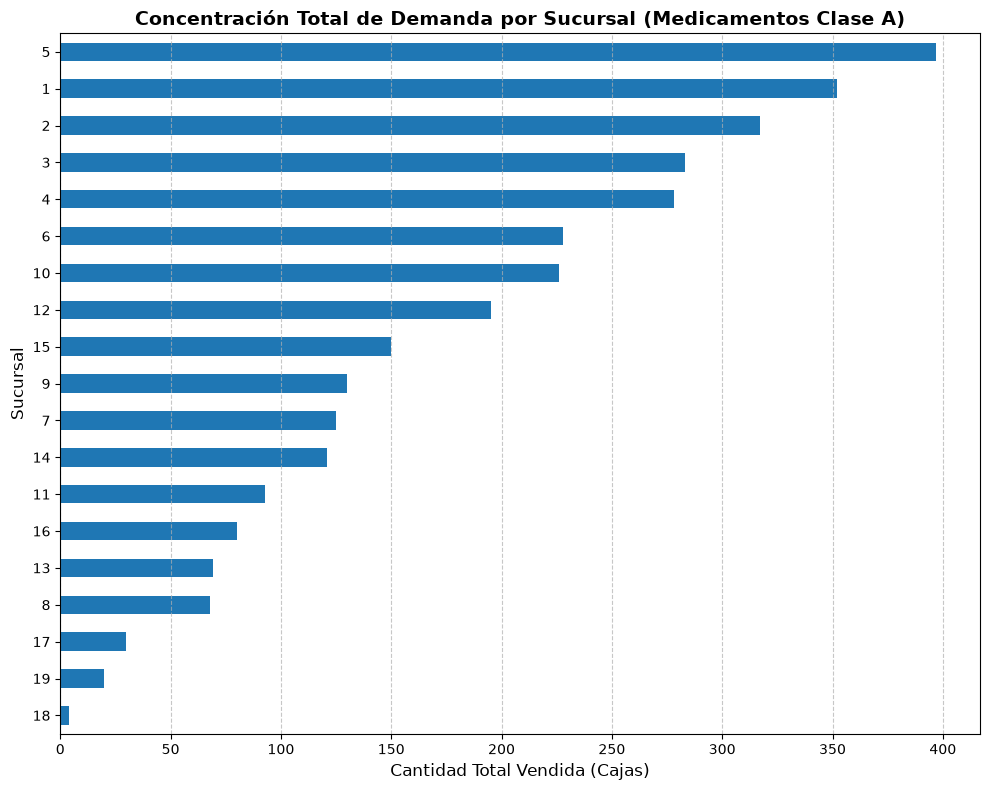

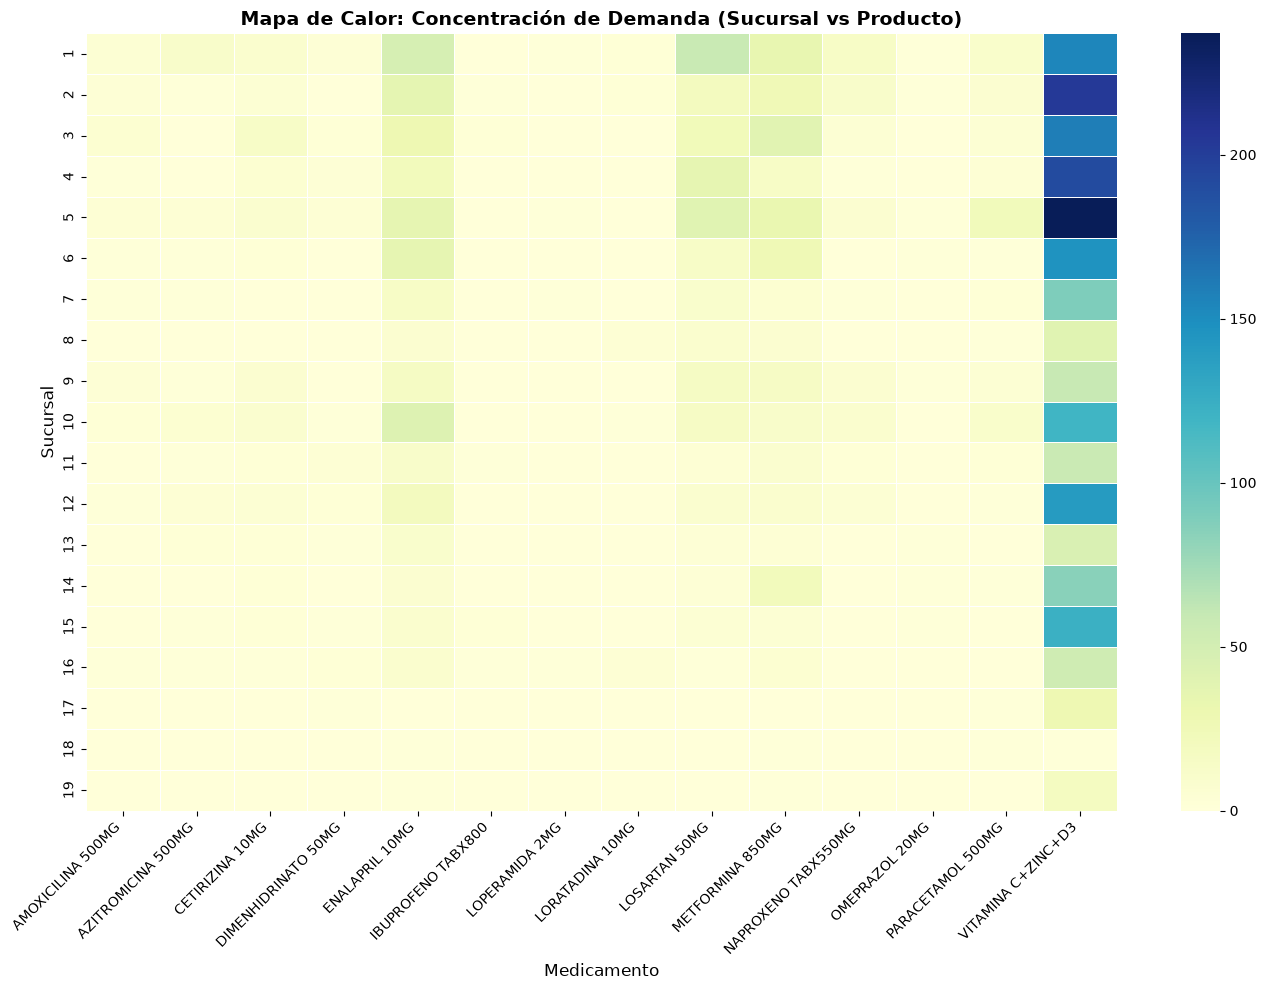

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset maestro
print("Cargando base de datos...")
df = pd.read_csv("../datasets/dataset_maestro_dashboard.csv")

# 2. Calcular la demanda total por sucursal
demanda_sucursal = df.groupby('sucursal')['cantidad'].sum().sort_values(ascending=True)

print("TOP 5 SUCURSALES CON MAYOR DEMANDA:")
print(demanda_sucursal.tail(5).sort_values(ascending=False))
print("-" * 50)
print("TOP 5 SUCURSALES CON MENOR DEMANDA (Más propensas a intermitencia):")
print(demanda_sucursal.head(5))

# 3. Graficar el volumen total por sucursal
plt.figure(figsize=(10, 8))
demanda_sucursal.plot(kind='barh', color='#1f77b4')
plt.title('Concentración Total de Demanda por Sucursal (Medicamentos Clase A)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad Total Vendida (Cajas)', fontsize=12)
plt.ylabel('Sucursal', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Matriz de calor (Heatmap): Sucursal vs Medicamento
# Esto muestra exactamente qué medicamento se vende más en qué sucursal
matriz_demanda = df.pivot_table(index='sucursal', columns='producto', values='cantidad', aggfunc='sum', fill_value=0)

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_demanda, cmap='YlGnBu', linewidths=.5, fmt=".0f", annot=False)
plt.title('Mapa de Calor: Concentración de Demanda (Sucursal vs Producto)', fontsize=14, fontweight='bold')
plt.xlabel('Medicamento', fontsize=12)
plt.ylabel('Sucursal', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

TOP 5 MEDICAMENTOS MÁS VENDIDOS EN SUCURSALES DE ALTA DEMANDA (Sucursales 1, 2, 3, 4, 5):
producto
VITAMINA C+ZINC+D3    944.0
LOSARTAN 50MG         178.0
ENALAPRIL 10MG        171.0
METFORMINA 850MG      144.0
PARACETAMOL 500MG      50.0
Name: cantidad, dtype: float64
------------------------------------------------------------
TOP 5 MEDICAMENTOS MÁS VENDIDOS EN SUCURSALES INTERMITENTES (Sucursales 8, 13, 17, 18, 19):
producto
VITAMINA C+ZINC+D3    133.0
ENALAPRIL 10MG         19.0
METFORMINA 850MG       13.0
LOSARTAN 50MG          12.0
LORATADINA 10MG         4.0
Name: cantidad, dtype: float64
------------------------------------------------------------


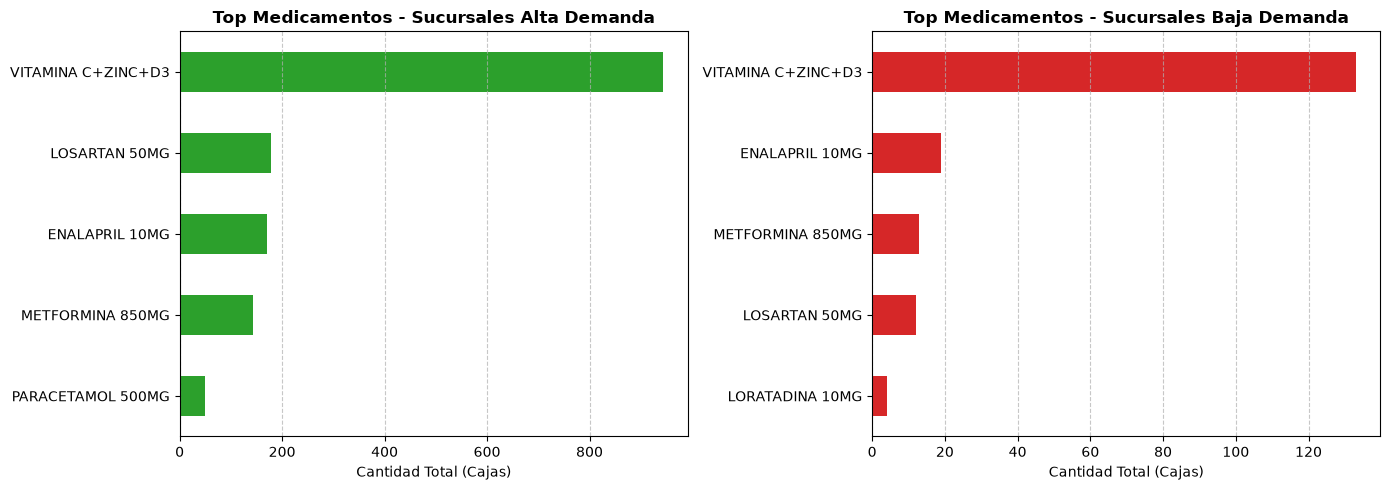

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar la carga de datos
df = pd.read_csv("../datasets/dataset_maestro_dashboard.csv")

# 2. Definir las sucursales extremas detectadas en el análisis previo
top_5_sucursales = [5, 1, 2, 3, 4]
bottom_5_sucursales = [18, 19, 17, 8, 13]

# 3. Filtrar los conjuntos de datos
df_top5 = df[df['sucursal'].isin(top_5_sucursales)]
df_bottom5 = df[df['sucursal'].isin(bottom_5_sucursales)]

# 4. Agrupar la cantidad vendida por producto en cada segmento
productos_top5 = df_top5.groupby('producto')['cantidad'].sum().sort_values(ascending=False)
productos_bottom5 = df_bottom5.groupby('producto')['cantidad'].sum().sort_values(ascending=False)

# 5. Imprimir los resultados numéricos
print("TOP 5 MEDICAMENTOS MÁS VENDIDOS EN SUCURSALES DE ALTA DEMANDA (Sucursales 1, 2, 3, 4, 5):")
print(productos_top5.head(5))
print("-" * 60)
print("TOP 5 MEDICAMENTOS MÁS VENDIDOS EN SUCURSALES INTERMITENTES (Sucursales 8, 13, 17, 18, 19):")
print(productos_bottom5.head(5))
print("-" * 60)

# 6. Visualización Comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Top 5
productos_top5.head(5).sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='#2ca02c')
axes[0].set_title('Top Medicamentos - Sucursales Alta Demanda', fontweight='bold')
axes[0].set_xlabel('Cantidad Total (Cajas)')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Gráfico Bottom 5
productos_bottom5.head(5).sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='#d62728')
axes[1].set_title('Top Medicamentos - Sucursales Baja Demanda', fontweight='bold')
axes[1].set_xlabel('Cantidad Total (Cajas)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor # <-- CAMBIO A XGBOOST

# 1. Cargar y preparar los datos
print("Cargando y procesando el dataset transaccional...")
df = pd.read_csv("../datasets/dataset_maestro_dashboard.csv")
df['fecdoc'] = pd.to_datetime(df['fecdoc'])
df = df.sort_values(by=['sucursal', 'producto', 'fecdoc']).reset_index(drop=True)

# Ingeniería de características
df['lag_1'] = df.groupby(['sucursal', 'producto'])['cantidad'].shift(1)
df['rolling_mean_7'] = df.groupby(['sucursal', 'producto'])['cantidad'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df['rolling_mean_30'] = df.groupby(['sucursal', 'producto'])['cantidad'].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
df['mes'] = df['fecdoc'].dt.month
df['dia_semana'] = df['fecdoc'].dt.dayofweek
df = df.dropna().reset_index(drop=True)

# Codificación One-Hot
df_encoded = pd.get_dummies(df, columns=['sucursal', 'producto'], drop_first=True)

# 2. Filtrar y definir variables (X, y)
columnas_a_excluir = ['fecdoc', 'cantidad', 'categoria_abc']
X_total_bruto = df_encoded.drop(columns=[col for col in columnas_a_excluir if col in df_encoded.columns])
X_total = X_total_bruto.select_dtypes(include=[np.number, bool])
y_total = df_encoded['cantidad']

# 3. Entrenar el modelo óptimo con el 100% de la historia
print("Entrenando XGBoost final con el 100% de los datos históricos...")
xgb_final = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_final.fit(X_total, y_total)

# 4. EXPORTACIÓN (FASE DE DESPLIEGUE)
ruta_modelo = "modelo_xgb_optimo.pkl" # <-- NUEVO NOMBRE DE ARCHIVO
joblib.dump(xgb_final, ruta_modelo)
print(f"Proceso finalizado. Modelo exportado con éxito en: {ruta_modelo}")

Cargando y procesando el dataset transaccional...


Entrenando XGBoost final con el 100% de los datos históricos...
Proceso finalizado. Modelo exportado con éxito en: modelo_xgb_optimo.pkl


In [7]:
import sys
import json
import hashlib
import platform
from pathlib import Path
import importlib.metadata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.demanda_semanal import (
    CLAVES, NUMERICAS, construir_semanal, agregar_features, particiones_por_semana)

ruta_datos = Path('../datasets/dataset_maestro_dashboard.csv')
salida = Path('../resultados/semanal')
salida.mkdir(parents=True, exist_ok=True)
fecha_corte = '2026-01-01'
df = pd.read_csv(ruta_datos)
df['fecdoc'] = pd.to_datetime(df['fecdoc'], errors='raise')
resumen_original = {
    'registros_transaccionales': len(df),
    'inicio': str(df.fecdoc.min()), 'fin': str(df.fecdoc.max()),
    'sucursales': int(df.sucursal.nunique()), 'productos': int(df.producto.nunique()),
    'combinaciones_potenciales': int(df.sucursal.nunique() * df.producto.nunique()),
    'combinaciones_observadas': int(df.groupby(CLAVES).ngroups),
    'sha256_dataset': hashlib.sha256(ruta_datos.read_bytes()).hexdigest()
}
display(pd.DataFrame([resumen_original]))
if len(df) != 37773:
    print('ADVERTENCIA: el CSV contiene', len(df), 'filas, no las 37 773 declaradas; no se fuerza el conteo.')
semanal = construir_semanal(df)
semanal.to_csv(salida / 'dataset_semanal.csv', index=False)
print('Observaciones semanales:', len(semanal))
print('Rango semanal:', semanal.semana.min(), semanal.semana.max())

,registros_transaccionales,inicio,fin,sucursales,productos,combinaciones_potenciales,combinaciones_observadas,sha256_dataset
0,44389,2024-01-01 00:00:00,2026-07-30 22:20:28,19,14,266,240,d57f432caea468ab5599dc0a73b2bdf0a5ac63ece3d505...


ADVERTENCIA: el CSV contiene 44389 filas, no las 37 773 declaradas; no se fuerza el conteo.


Observaciones semanales: 21123
Rango semanal: 2024-01-07 00:00:00 2026-08-02 00:00:00


## Ceros, escala y disponibilidad de datos
Se completan con cero exclusivamente semanas sin registros dentro del primer y último registro de cada serie observada. Si existen NaN o valores no finitos en los campos requeridos, se detiene el proceso; no se reinterpretan como ceros. El CSV no permite distinguir ausencia de ventas de interrupciones de captura no registradas: el relleno presupone continuidad del sistema dentro de ese rango.

`cantidad` representa cajas según el esquema del proyecto. Una fila con cajas cero puede tener unidades vendidas; no equivale necesariamente a demanda farmacéutica nula. Los descriptivos y el histograma incluyen las semanas cero. No se excluyen series por intermitencia.

El CSV actual tiene 44 389 filas. El conteo anterior de 37 773 se reproduce después de calcular los lags transaccionales antiguos y aplicar `dropna()`: no es el tamaño original del CSV. Se detectaron 74 registros con cantidad negativa y dos semanas con total negativo; se conservan y deben verificarse como posibles devoluciones o ajustes antes de interpretar el target como demanda bruta.

Cantidades negativas transaccionales: 74
Las cantidades negativas se conservan; verificar si son devoluciones o ajustes.


,cantidad_semanal
count,21123.000000
mean,0.149884
std,0.577957
min,-10.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,14.000000
median,0.000000
porcentaje_ceros,90.455901


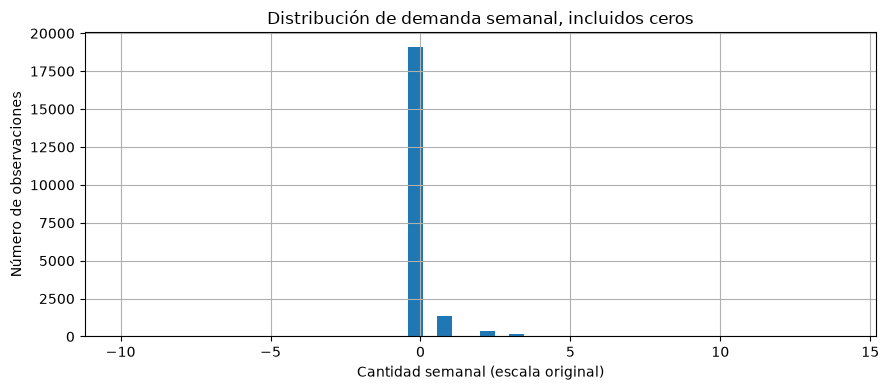

In [8]:
descriptivos = semanal['cantidad'].describe().to_frame('cantidad_semanal')
descriptivos.loc['median'] = semanal.cantidad.median()
descriptivos.loc['porcentaje_ceros'] = semanal.cantidad.eq(0).mean() * 100
descriptivos.loc['valores_positivos'] = semanal.cantidad.gt(0).sum()
descriptivos.loc['valores_negativos'] = semanal.cantidad.lt(0).sum()
print('Cantidades negativas transaccionales:', df.cantidad.lt(0).sum())
print('Las cantidades negativas se conservan; verificar si son devoluciones o ajustes.')
display(descriptivos)
descriptivos.to_csv(salida / 'descriptivos_semanales.csv')
semanal.cantidad.hist(bins=50, figsize=(9, 4))
plt.xlabel('Cantidad semanal (escala original)')
plt.ylabel('Número de observaciones')
plt.title('Distribución de demanda semanal, incluidos ceros')
plt.tight_layout()
plt.show()

## Características causales y eliminación del historial insuficiente
`lag_1`, `lag_2`, `lag_4` y `lag_8` son demandas de 1, 2, 4 y 8 semanas anteriores dentro de la misma sucursal-producto. Las medias de 4 y 8 semanas usan `shift(1)` y requieren la ventana completa. Mes, semana ISO y trimestre provienen del calendario de la semana a pronosticar.

Se eliminan las primeras ocho semanas de cada serie (o toda la serie si no supera ocho observaciones). Se informa el número exacto, separado por train/test. Las features del test utilizan únicamente semanas anteriores: este es un protocolo secuencial de una semana con parámetros fijos durante el test; no es una predicción simultánea de todo 2026 desde enero. La misma disponibilidad secuencial se aplica dentro de cada bloque de validación.

In [9]:
con_features = agregar_features(semanal)
sin_historia = con_features[NUMERICAS].isna().any(axis=1)
datos_modelo = con_features.loc[~sin_historia].sort_values(
    ['semana', 'sucursal', 'producto'], kind='stable').reset_index(drop=True)
df_train = datos_modelo[datos_modelo.semana < fecha_corte].copy()
df_test = datos_modelo[datos_modelo.semana >= fecha_corte].copy()
assert not df_train.empty and not df_test.empty
assert df_train.semana.max() < df_test.semana.min()
resumen_semanal = {
    'observaciones_semanales': len(semanal),
    'train_antes_lags': int(semanal.semana.lt(fecha_corte).sum()),
    'test_antes_lags': int(semanal.semana.ge(fecha_corte).sum()),
    'eliminadas_por_lags': int(sin_historia.sum()),
    'eliminadas_train': int((sin_historia & con_features.semana.lt(fecha_corte)).sum()),
    'eliminadas_test': int((sin_historia & con_features.semana.ge(fecha_corte)).sum()),
    'train_modelo': len(df_train), 'test_modelo': len(df_test),
    'series_con_historia': int(datos_modelo.groupby(CLAVES).ngroups),
    'series_test': int(df_test.groupby(CLAVES).ngroups),
    'porcentaje_ceros_global': float(semanal.cantidad.eq(0).mean() * 100),
    'inicio_semanal': str(semanal.semana.min()), 'fin_semanal': str(semanal.semana.max())
}
display(pd.DataFrame([resumen_semanal]))
X_train = df_train[CLAVES + NUMERICAS]
X_test = df_test[CLAVES + NUMERICAS]
y_train, y_test = df_train.cantidad, df_test.cantidad
print('Dimensiones antes de One-Hot:', X_train.shape, X_test.shape)
for columna in CLAVES:
    nuevas = sorted(set(X_test[columna]) - set(X_train[columna]))
    print(f'Categorías de {columna} presentes sólo en TEST:', nuevas)


,observaciones_semanales,train_antes_lags,test_antes_lags,eliminadas_por_lags,eliminadas_train,eliminadas_test,train_modelo,test_modelo,series_con_historia,series_test,porcentaje_ceros_global,inicio_semanal,fin_semanal
0,21123,16860,4263,1881,1690,191,15170,4072,232,158,90.455901,2024-01-07 00:00:00,2026-08-02 00:00:00


Dimensiones antes de One-Hot: (15170, 11) (4072, 11)
Categorías de sucursal presentes sólo en TEST: [17, 18, 19]
Categorías de producto presentes sólo en TEST: []


## Validación temporal y categorías
Se usa `TimeSeriesSplit(n_splits=3)` sobre las semanas únicas del train y se convierten sus posiciones a filas para `GridSearchCV`. Así ninguna semana se reparte entre entrenamiento y validación, aunque contenga varias sucursales. No hay shuffle ni selección con test.

El One-Hot Encoder está dentro del Pipeline: se ajusta sólo con el entrenamiento de cada fold y, en el ajuste final, sólo con todo TRAIN. TEST utiliza ese mismo transformador. Categorías desconocidas se representan con ceros (`handle_unknown='ignore'`); la categoría de referencia se omite (`drop='first'`). Se conservan categorías conocidas sin consultar el futuro. La selección minimiza MSE de validación (`best_score_` es MSE negativo), con rejillas moderadas y semilla 42.

In [10]:
class MachineLearningPipeline:
    def __init__(self, X_train, y_train, X_test, y_test, fechas_train, claves_test):
        self.X_train, self.y_train = X_train, y_train
        self.X_test, self.y_test = X_test, y_test
        self.claves_test = claves_test.copy()
        self.resultados, self.predicciones, self.modelos = [], {}, {}
        self.best_params_, self.best_score_, self.cv_results_ = {}, {}, {}
        self.cv = particiones_por_semana(fechas_train, n_splits=3)

    def _pipeline(self, modelo):
        preprocesador = ColumnTransformer([
            ('categorias', OneHotEncoder(handle_unknown='ignore', drop='first',
                                          sparse_output=False), CLAVES),
            ('numericas', 'passthrough', NUMERICAS)
        ])
        return Pipeline([('preprocesador', preprocesador), ('modelo', modelo)])

    def _registrar_metricas(self, nombre_modelo, predicciones):
        detalle = self.claves_test.copy()
        detalle['y_real'] = np.asarray(self.y_test, dtype=float)
        detalle['y_pred'] = np.asarray(predicciones, dtype=float)
        if not np.isfinite(detalle[['y_real', 'y_pred']]).all().all():
            raise ValueError('Valores no finitos en la evaluación')
        detalle['error'] = detalle.y_real - detalle.y_pred
        detalle['error_absoluto'] = detalle.error.abs()
        self.predicciones[nombre_modelo] = detalle
        self.resultados.append({
            'Modelo': nombre_modelo,
            'MAE': mean_absolute_error(detalle.y_real, detalle.y_pred),
            'RMSE': np.sqrt(mean_squared_error(detalle.y_real, detalle.y_pred)),
            'R2': r2_score(detalle.y_real, detalle.y_pred),
            'Best Params': self.best_params_.get(nombre_modelo, {}),
            'CV neg_MSE': self.best_score_.get(nombre_modelo, np.nan)
        })

    def ejecutar_regresion_lineal(self):
        nombre = 'Regresión Lineal'
        modelo = self._pipeline(LinearRegression())
        modelo.fit(self.X_train, self.y_train)
        self.modelos[nombre] = modelo
        self._registrar_metricas(nombre, modelo.predict(self.X_test))

    def _buscar(self, nombre, estimador, rejilla):
        grid = GridSearchCV(self._pipeline(estimador),
                            {f'modelo__{k}': v for k, v in rejilla.items()},
                            cv=self.cv, scoring='neg_mean_squared_error',
                            n_jobs=1, error_score='raise', refit=True)
        grid.fit(self.X_train, self.y_train)
        self.modelos[nombre] = grid.best_estimator_
        self.best_params_[nombre] = {k.removeprefix('modelo__'): v for k, v in grid.best_params_.items()}
        self.best_score_[nombre] = float(grid.best_score_)
        self.cv_results_[nombre] = pd.DataFrame(grid.cv_results_)
        print(nombre, 'best_params_:', self.best_params_[nombre])
        print(nombre, 'best_score_ (MSE negativo):', grid.best_score_)
        self._registrar_metricas(nombre, grid.predict(self.X_test))

    def ejecutar_random_forest(self):
        self._buscar('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), {
            'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2]})

    def ejecutar_xgboost(self):
        self._buscar('XGBoost', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1), {
            'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]})

    def obtener_tabla_resultados(self):
        return pd.DataFrame(self.resultados).sort_values('RMSE').reset_index(drop=True)

pipeline = MachineLearningPipeline(X_train, y_train, X_test, y_test,
                                   df_train.semana, df_test[CLAVES + ['semana']])
folds = []
for i, (a, b) in enumerate(pipeline.cv, 1):
    folds.append({'fold': i, 'filas_train': len(a), 'filas_validacion': len(b),
                  'train_inicio': str(df_train.semana.iloc[a].min()),
                  'train_fin': str(df_train.semana.iloc[a].max()),
                  'validacion_inicio': str(df_train.semana.iloc[b].min()),
                  'validacion_fin': str(df_train.semana.iloc[b].max())})
display(pd.DataFrame(folds))

,fold,filas_train,filas_validacion,train_inicio,train_fin,validacion_inicio,validacion_fin
0,1,2967,3732,2024-03-03 00:00:00,2024-08-11 00:00:00,2024-08-18 00:00:00,2025-01-26 00:00:00
1,2,6699,4357,2024-03-03 00:00:00,2025-01-26 00:00:00,2025-02-02 00:00:00,2025-07-13 00:00:00
2,3,11056,4114,2024-03-03 00:00:00,2025-07-13 00:00:00,2025-07-20 00:00:00,2025-12-28 00:00:00


In [11]:
pipeline.ejecutar_regresion_lineal()
pipeline.ejecutar_random_forest()
pipeline.ejecutar_xgboost()
tabla_final = pipeline.obtener_tabla_resultados()
display(tabla_final)
tabla_final.to_csv(salida / 'metricas_ml_semanal.csv', index=False)
for nombre, detalle in pipeline.predicciones.items():
    detalle.to_csv(salida / f'predicciones_{nombre.replace(" ", "_")}_semanal.csv', index=False)
for nombre, resultados_cv in pipeline.cv_results_.items():
    resultados_cv.to_csv(salida / f'cv_{nombre.replace(" ", "_")}.csv', index=False)

versiones = {p: importlib.metadata.version(p) for p in
             ['pandas', 'numpy', 'scikit-learn', 'xgboost', 'statsmodels', 'joblib']}
manifiesto = {'dataset_original': resumen_original, 'dataset_semanal': resumen_semanal,
              'fecha_corte': fecha_corte, 'frecuencia': 'W-SUN',
              'protocolo_ml': 'una semana secuencial; sin reentrenar durante test',
              'folds': folds, 'best_params': pipeline.best_params_,
              'best_score_neg_mse': pipeline.best_score_,
              'python': platform.python_version(), 'versiones': versiones}
(salida / 'experimento_ml.json').write_text(json.dumps(manifiesto, indent=2, ensure_ascii=False), encoding='utf-8')
print('Resultados y predicciones guardados en', salida.resolve())

Random Forest best_params_: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest best_score_ (MSE negativo): -0.24748964825275496


XGBoost best_params_: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost best_score_ (MSE negativo): -0.2327766347998478


,Modelo,MAE,RMSE,R2,Best Params,CV neg_MSE
0,Regresión Lineal,0.212786,0.503876,0.321588,{},NaN
1,XGBoost,0.204510,0.509719,0.305764,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",-0.232777
2,Random Forest,0.205781,0.515537,0.289823,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",-0.247490


Resultados y predicciones guardados en C:\Users\USER\Desktop\Project-LF\Modelos_ML\resultados\semanal


## Interpretación y serialización
MAE resume error absoluto medio; RMSE penaliza errores grandes y R² compara con predecir la media del test. Las métricas se calculan sobre exactamente las mismas filas de test en los tres modelos supervisados y no se redondean internamente. No se recortan predicciones negativas.

La tabla ordenada por RMSE no declara un ganador general del estudio. Se informa el contraste de las tres métricas. Como regla conservadora para guardar el nuevo artefacto XGBoost, se exige que tenga el menor RMSE, el mayor R² y no empeore el menor MAE de los tres modelos. Esto no ajusta hiperparámetros con test: sólo decide si se guarda el estimador ya evaluado. El archivo anterior permanece intacto. Se guarda el Pipeline completo entrenado sólo con TRAIN, sin reentrenarlo con el test y sin atribuirle métricas de un ajuste diferente.

ARIMA conserva evaluación de horizonte múltiple y filtros de longitud propios. Antes de afirmar superioridad entre los cuatro modelos habría que emparejar también horizonte y cobertura, no sólo frecuencia. El cuaderno 06 presenta sus métricas consolidadas por separado.

In [12]:
tabla = tabla_final.set_index('Modelo')
xgb = tabla.loc['XGBoost']
print('Menor MAE:', tabla.MAE.idxmin())
print('Menor RMSE:', tabla.RMSE.idxmin())
print('Mayor R2:', tabla.R2.idxmax())
if xgb.RMSE <= tabla.RMSE.min() and xgb.R2 >= tabla.R2.max() and xgb.MAE <= tabla.MAE.min():
    ruta_modelo = Path('modelo_xgb_optimo_semanal.pkl')
    joblib.dump(pipeline.modelos['XGBoost'], ruta_modelo)
    print('Guardado Pipeline semanal entrenado sólo en TRAIN:', ruta_modelo)
else:
    print('No se serializa XGBoost: no domina conjuntamente las tres métricas.')

Menor MAE: XGBoost
Menor RMSE: Regresión Lineal
Mayor R2: Regresión Lineal
No se serializa XGBoost: no domina conjuntamente las tres métricas.
